In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [3]:
# Data Loading
import pandas as pd

df = pd.read_csv("/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
#Data Understanding and Cleaning
df.shape

(2640, 12)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [6]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [7]:
missing_values = df.isnull().sum()
print("Missing values in each column:", missing_values)

Missing values in each column: Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64


In [8]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


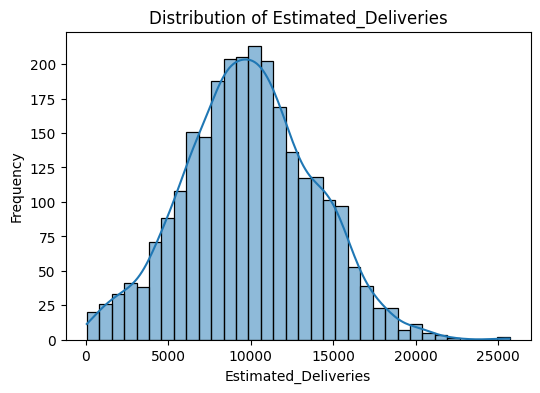

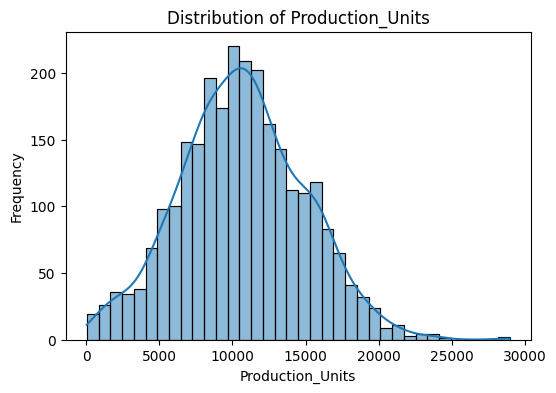

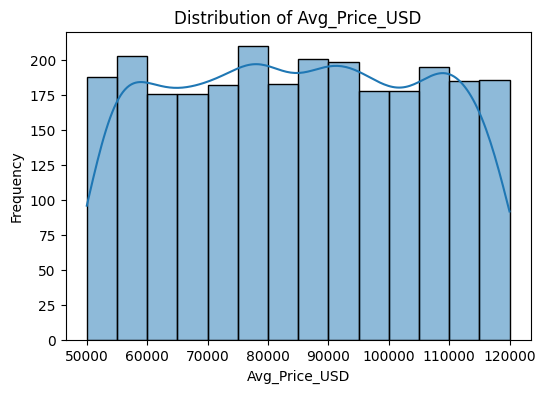

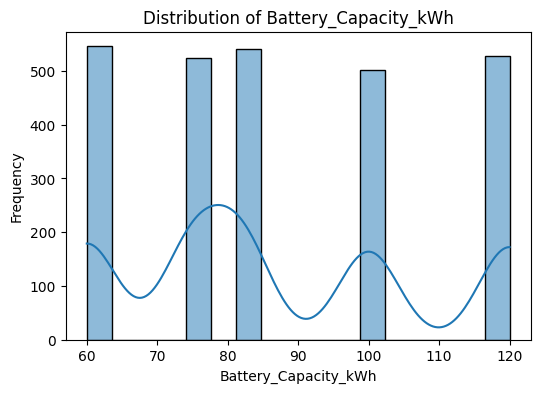

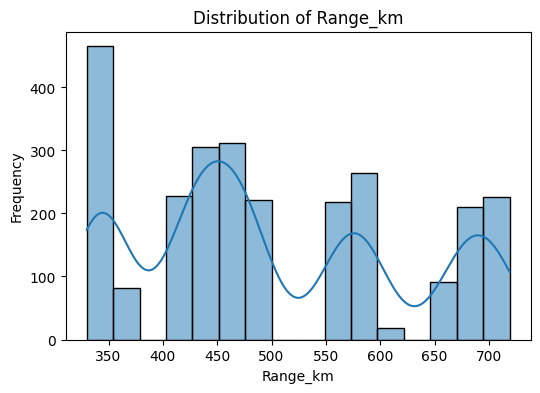

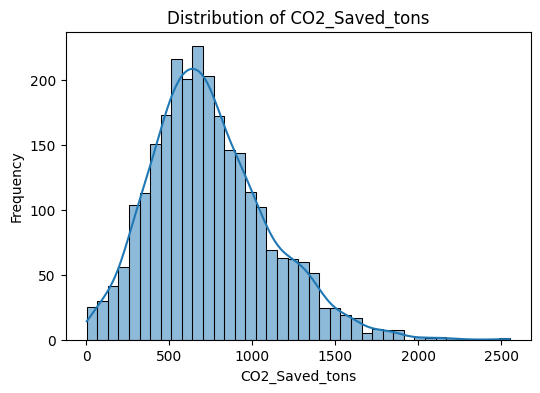

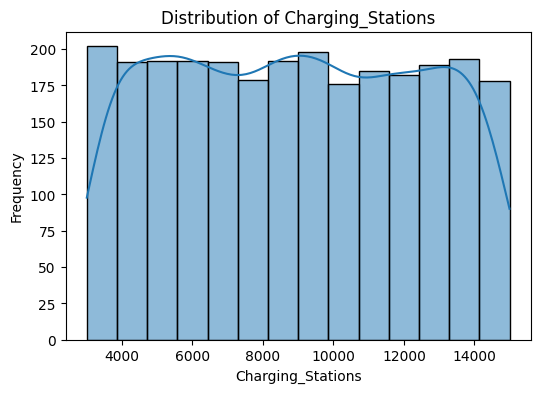

In [9]:
# Exploratory Data Analysis (EDA)
# -Univariate Analysis
numerical_cols = [
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]

for col in numerical_cols:
    plt.figure(figsize=(6,4))

    sns.histplot(df[col], kde=True)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()


In [10]:
# -Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

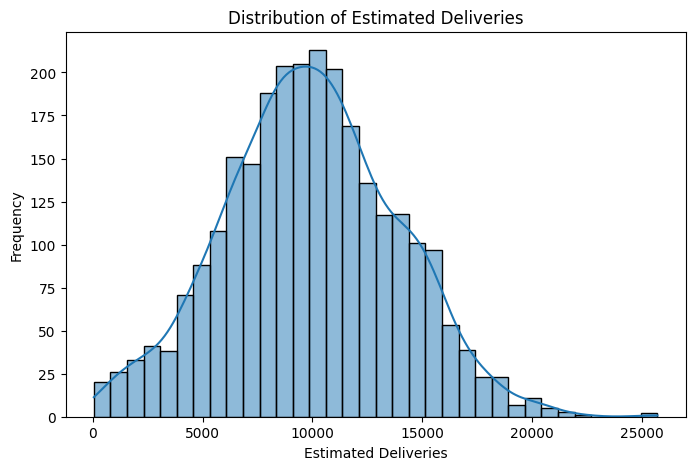

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Estimated_Deliveries'],
    kde=True
)

plt.title('Distribution of Estimated Deliveries')
plt.xlabel('Estimated Deliveries')
plt.ylabel('Frequency')

plt.show()

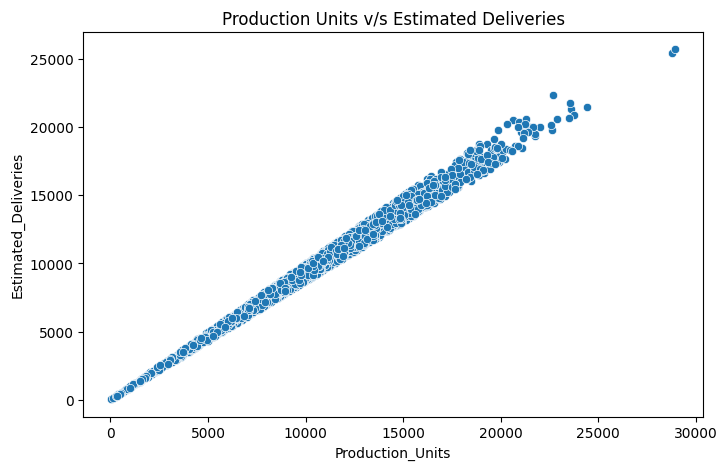

In [12]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Production_Units',
    y='Estimated_Deliveries',
    data=df
)

plt.title('Production Units v/s Estimated Deliveries')

plt.show()

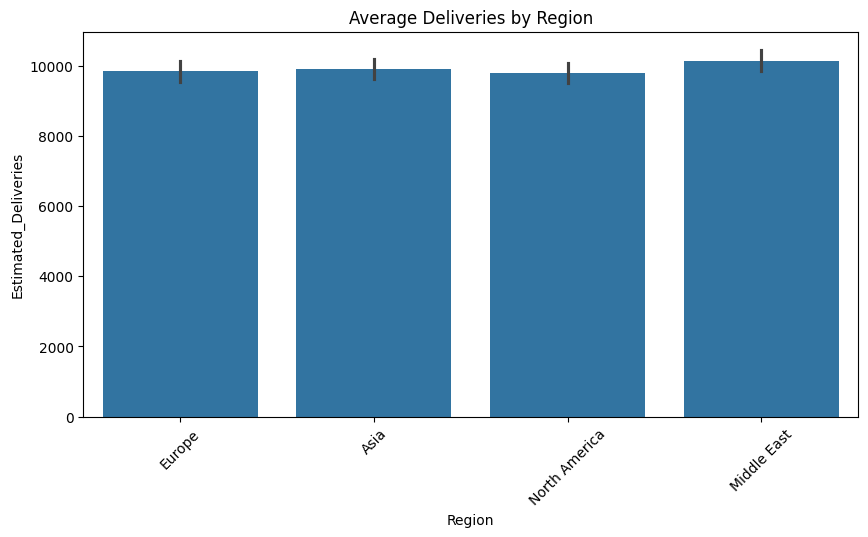

In [13]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Region',
    y='Estimated_Deliveries',
    data=df
)

plt.title('Average Deliveries by Region')
plt.xticks(rotation=45)
plt.show()

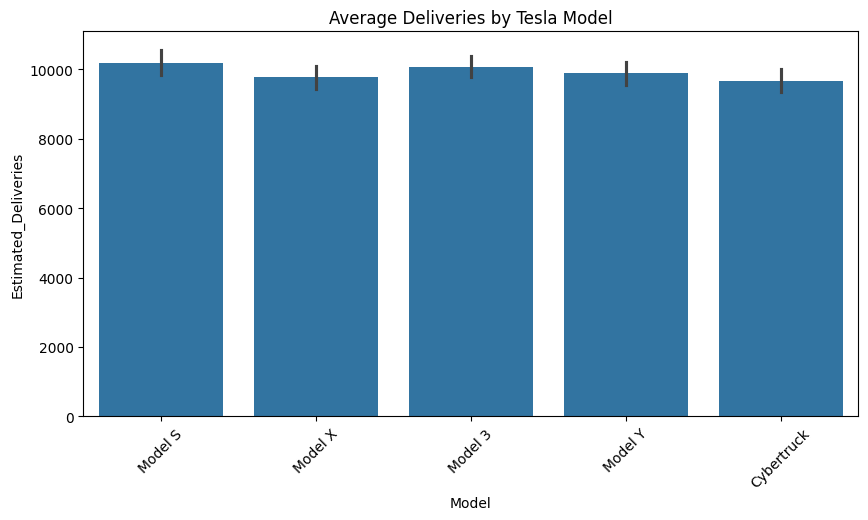

In [14]:
plt.figure(figsize=(10,5))

sns.barplot(
    x='Model',
    y='Estimated_Deliveries',
    data=df
)

plt.title('Average Deliveries by Tesla Model')
plt.xticks(rotation=45)
plt.show()

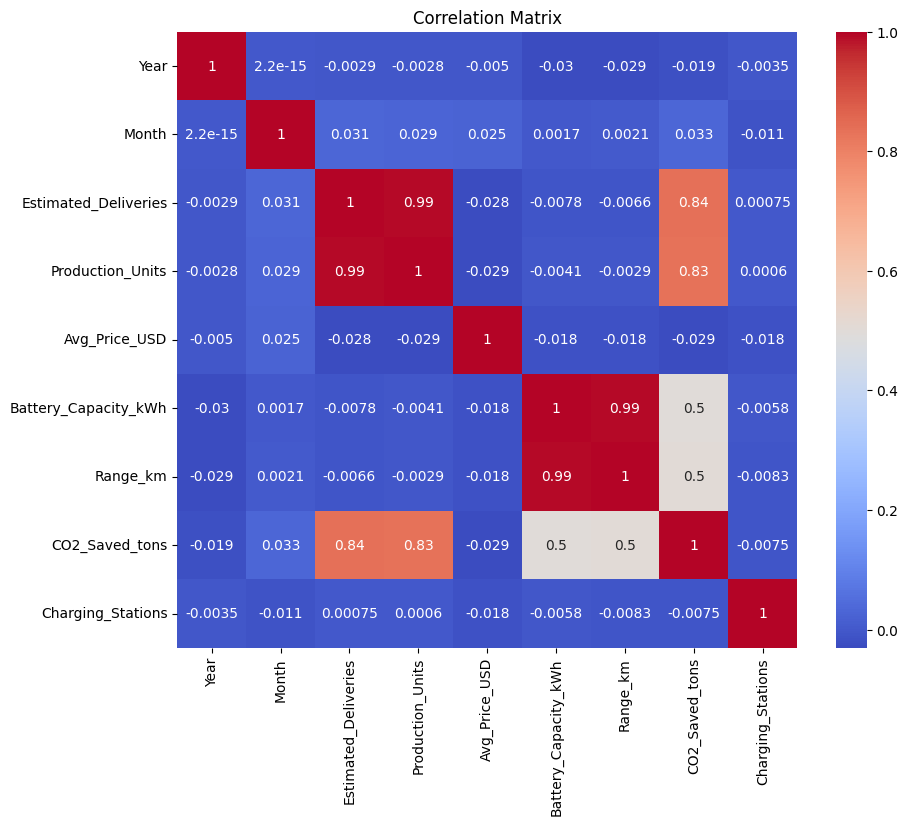

In [15]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

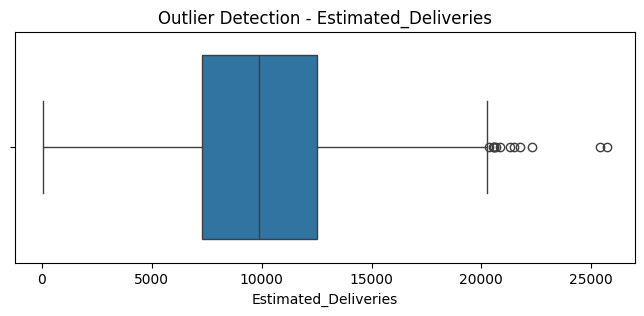

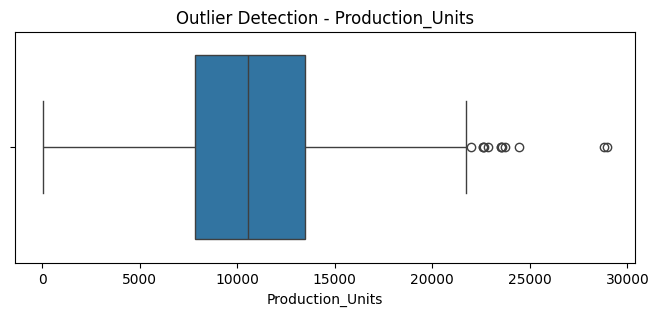

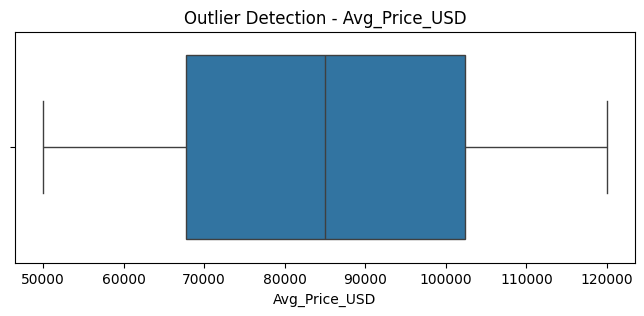

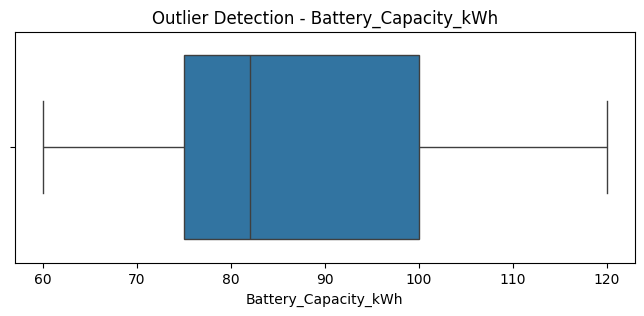

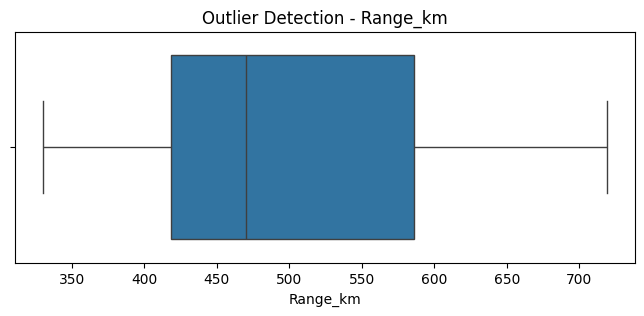

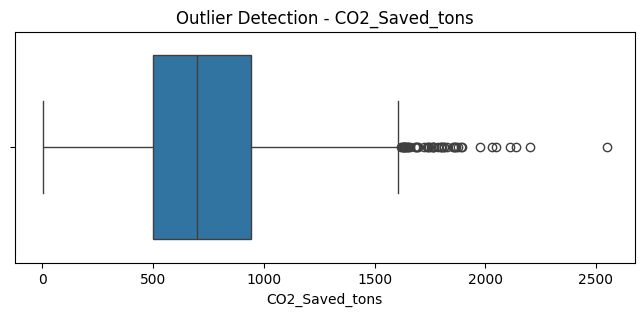

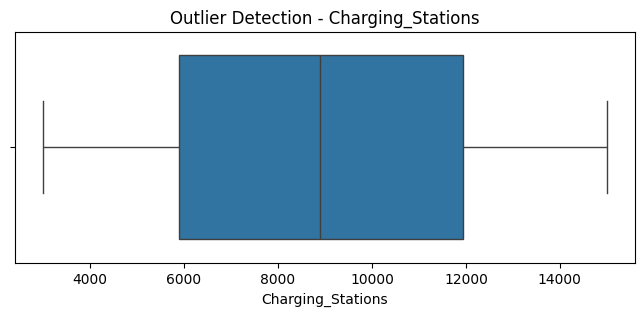

In [16]:
# -Outlier Detection
for col in numerical_cols:
    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f'Outlier Detection - {col}')
    plt.show()

In [17]:
# Feature Engineering

#Feature 1: Delivery Efficiency
df['Delivery_Efficiency']=(
    df['Estimated_Deliveries'] / df['Production_Units']
)

# Feature 2: Price per km
df['Price_Per_KM'] = (
    df['Avg_Price_USD'] / df['Range_km']
)

# Feature 3: CO2 per vehicle
df['CO2_Per_Vehicle'] = (
    df['CO2_Saved_tons'] / df['Estimated_Deliveries']
)

# Feature 4: Production Gap
df['Production_Gap'] = (
    df['Production_Units'] - df['Estimated_Deliveries']
)

# Feature 5: Date Column
df['Date'] = pd.to_datetime(
    df['Year'].astype(str) + '-' + df['Month'].astype(str)
)

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Delivery_Efficiency,Price_Per_KM,CO2_Per_Vehicle,Production_Gap,Date
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,0.984600,131.923679,0.105600,276,2023-05-01
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640,0.911864,142.022032,0.065699,367,2015-02-01
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071,0.915334,245.598583,0.072000,778,2019-01-01
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333,0.896594,125.414199,0.106799,756,2021-02-01
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722,0.914087,173.747020,0.099150,1163,2016-12-01


In [18]:
# Data Leakage Analysis
leakage_features = [
    'Delivery_Efficiency',
    'Production_Gap',
    'CO2_Per_Vehicle'
]

print("Potential Leakage Features:")
print(leakage_features)

Potential Leakage Features:
['Delivery_Efficiency', 'Production_Gap', 'CO2_Per_Vehicle']


In [19]:
X_safe = df.drop(
    [
        'Estimated_Deliveries',
        'Date',
        'Delivery_Efficiency',
        'Production_Gap',
        'CO2_Per_Vehicle'
    ],axis=1)

X_safe.head()

,Year,Month,Region,Model,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Price_Per_KM
0,2023,5,Europe,Model S,17922,92874.27,120,704,1863.42,Interpolated (Month),12207,131.923679
1,2015,2,Asia,Model X,4164,62205.65,75,438,249.46,Official (Quarter),7640,142.022032
2,2019,1,North America,Model X,9189,117887.32,82,480,605.59,Interpolated (Month),14071,245.598583
3,2021,2,North America,Model 3,7311,89294.91,120,712,700.07,Official (Quarter),9333,125.414199
4,2016,12,Middle East,Model Y,13537,114846.78,120,661,1226.88,Estimated (Region),8722,173.747020


In [20]:
# Data Preprocessing (Encoding)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Region'] = le.fit_transform(df['Region'])
df['Model'] = le.fit_transform(df['Model'])
df['Source_Type'] = le.fit_transform(df['Source_Type'])

df[['Region',
    'Model',
    'Source_Type']].head()

,Region,Model,Source_Type
0,1,2,1
1,0,3,2
2,3,3,1
3,3,1,2
4,2,4,0


In [21]:
y = df['Estimated_Deliveries']

X_safe = df.drop(
    [
        'Estimated_Deliveries',
        'Date',
        'Delivery_Efficiency',
        'Production_Gap',
        'CO2_Per_Vehicle'
    ],
    axis=1
)

In [22]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_safe)
print(X_scaled.shape)

(2640, 12)


In [23]:
# Regression Modeling
y = df['Estimated_Deliveries']
X_safe = df.drop(
    [
        'Estimated_Deliveries',
        'Date',
        'Delivery_Efficiency',
        'Production_Gap',
        'CO2_Per_Vehicle'
    ],axis=1)

X_safe.columns

Index(['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type',
       'Charging_Stations', 'Price_Per_KM'],
      dtype='object')

In [24]:
# Train-Test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (2112, 12)
Testing shape: (528, 12)


In [25]:
# Random Forest Regressor
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200, random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [26]:
pred = rf.predict(X_test)

comparison = pd.DataFrame({
    'Actual':y_test,
    'Predicted':pred
})

comparison.head()

,Actual,Predicted
2005,6991,7354.015
32,9326,9369.385
962,9061,8891.595
1461,8951,9398.760
478,8707,8846.790


In [27]:
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))
print("R2 Score:", r2_score(y_test, pred))

MAE: 325.0959090909091
RMSE: 410.0757838351022
R2 Score: 0.9887187107227322


In [28]:
# Cross Validation
from sklearn.model_selection import cross_val_score

In [29]:
cv_scores = cross_val_score(
    rf,X_scaled,y,cv=5,scoring='r2'
)

print("CV Scores:")
print(cv_scores)

print("Mean CV Scores:", cv_scores.mean())

CV Scores:
[0.98838505 0.98969565 0.98744644 0.99011498 0.99045919]
Mean CV Scores: 0.9892202608566467


In [30]:
# Feature Importance Analysis
importance = pd.DataFrame({
    'Feature': X_safe.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=True
)

importance.head(10)

,Feature,Importance
6,Battery_Capacity_kWh,0.000142
9,Source_Type,0.000268
2,Region,0.000380
3,Model,0.000457
1,Month,0.000708
0,Year,0.000803
11,Price_Per_KM,0.001014
5,Avg_Price_USD,0.001033
10,Charging_Stations,0.001042
7,Range_km,0.001237


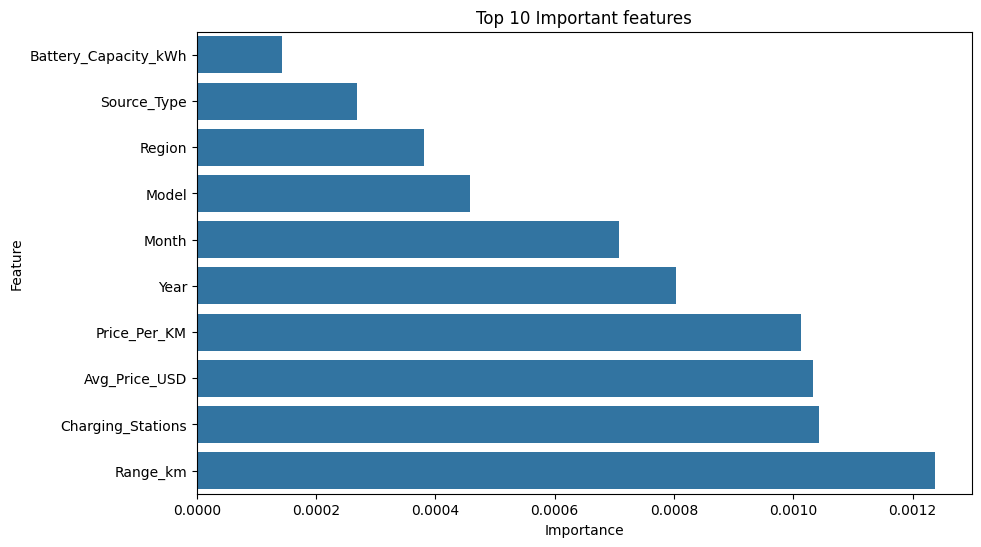

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance.head(10)
)

plt.title('Top 10 Important features')
plt.show()

In [32]:
# Hyperparameter Tuning using GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid, cv=3, scoring='r2', n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'max_depth': 10, 'n_estimators': 200}
Best Score: 0.9878995675173385


In [33]:
df[['Date', 'Estimated_Deliveries']].head()

,Date,Estimated_Deliveries
0,2023-05-01,17646
1,2015-02-01,3797
2,2019-01-01,8411
3,2021-02-01,6555
4,2016-12-01,12374


In [34]:
# Machine Learning Pipeline
from sklearn.pipeline import Pipeline

In [35]:
pipeline = Pipeline([
    (
        'scaler', 
        StandardScaler()
    ),
    (
        'model',
        RandomForestRegressor(
            n_estimators=200,
            max_depth=10,
            random_state=42
        )
    )
])

In [36]:
pipeline.fit(X_safe,y)
print("Pipeline Created Successfully")

Pipeline Created Successfully


In [37]:
# Model Comparison
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

In [38]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

In [39]:
comparison = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest'
    ],

    'MAE':[
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, dt_pred),
        mean_absolute_error(y_test, pred)
    ],

    'RMSE':[
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, dt_pred)),
        np.sqrt(mean_squared_error(y_test, pred))
    ],

    'R2 Score':[
        r2_score(y_test, lr_pred),
        r2_score(y_test, dt_pred),
        r2_score(y_test, pred)
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,310.007489,383.662744,0.990125
1,Decision Tree,400.549242,553.063644,0.979480
2,Random Forest,325.095909,410.075784,0.988719


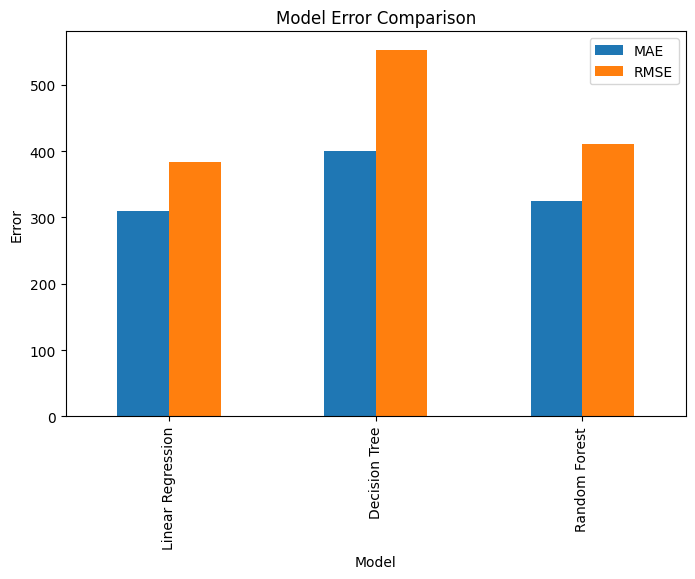

In [40]:
comparison.set_index('Model')[['MAE','RMSE']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Model Error Comparison')
plt.ylabel('Error')
plt.xlabel('Model')
plt.show()

## Model Comparison Observation

To identify the most suitable model for predicting Tesla deliveries, three regression algorithms were evaluated: Linear Regression, Decision Tree Regressor, and Random Forest Regressor. The models were compared using MAE, RMSE, and R² Score.

Among the evaluated models, Linear Regression achieved the best performance with the lowest MAE and RMSE values and the highest R² Score of 0.9901. This indicates that the relationship between the selected features and Tesla deliveries is largely linear.

Although Random Forest Regressor also achieved excellent results, Linear Regression provided slightly more accurate predictions on this dataset. Therefore, Linear Regression can be considered the most effective model for delivery prediction in this analysis.

In [41]:
# Time Series forecasting
ts = df.groupby('Date')['Estimated_Deliveries'].mean()

ts.head()

Date
2015-01-01     9159.00
2015-02-01     8252.65
2015-03-01     9228.35
2015-04-01    11281.15
2015-05-01     9213.20
Name: Estimated_Deliveries, dtype: float64

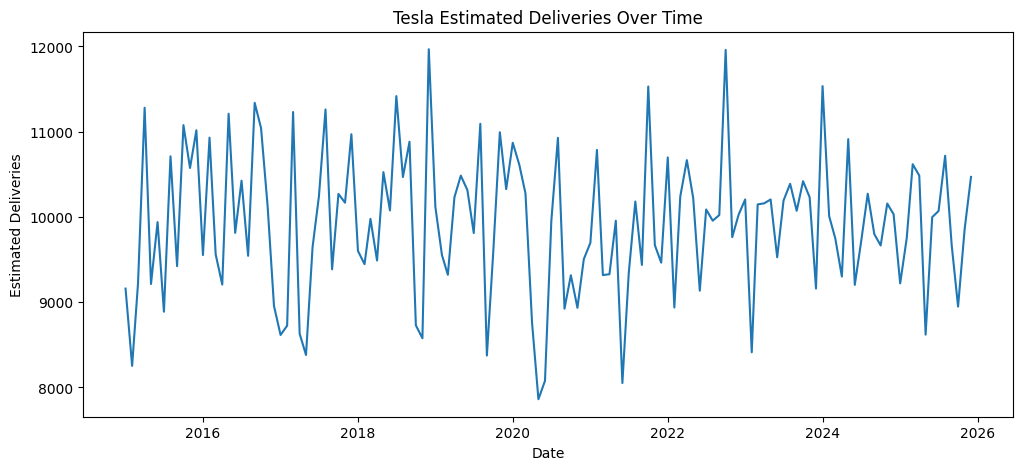

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(ts)

plt.title('Tesla Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')

plt.show()

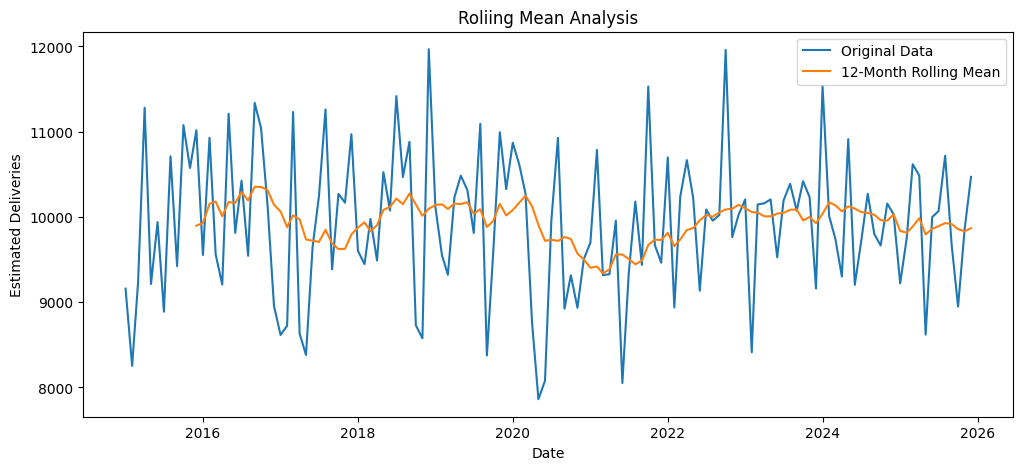

In [43]:
# Rolling Mean Analysis
rolling_mean = ts.rolling(window=12).mean()

plt.figure(figsize=(12,5))
plt.plot(
    ts,
    label='Original Data'
)

plt.plot(
    rolling_mean,
    label='12-Month Rolling Mean'
)

plt.title('Roliing Mean Analysis')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.show()

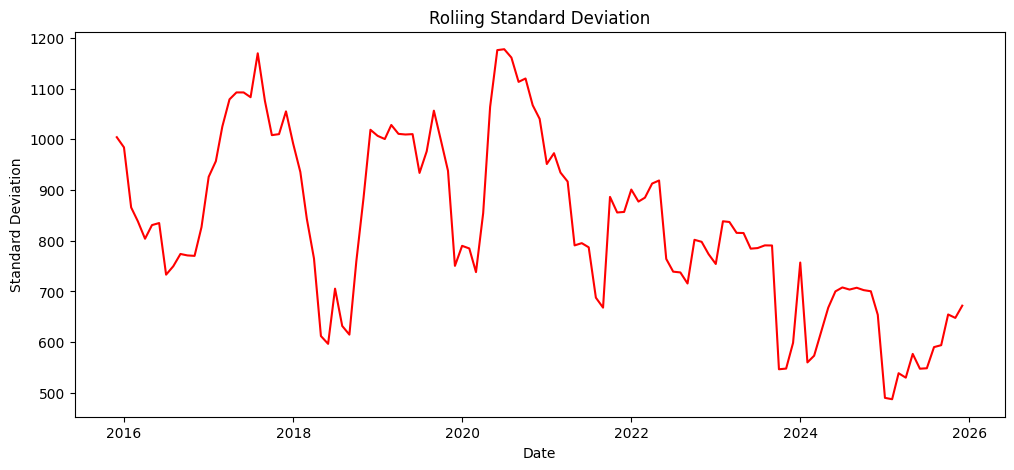

In [44]:
# Rolling Standard Deviation Analysis
rolling_std = ts.rolling(window=12).std()

plt.figure(figsize=(12,5))
plt.plot(
    rolling_std,
    color='red'
)

plt.title('Roliing Standard Deviation')
plt.xlabel('Date')
plt.ylabel('Standard Deviation')
plt.show()

In [45]:
# Stationarity Test using Augmented Dickey-Fuller (ADF)
from statsmodels.tsa.stattools import adfuller

In [46]:
result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -8.880990349502973
p-value: 1.3181396968145779e-14


If p-value < 0.05, indicating that the time series is stationary. Therefore, the series is suitable for ARIMA-based forecasting.
If p-value > 0.05, indicating that the time series is non-stationary. Differencing is required to make the series stationary before forecasting.

In [47]:
from statsmodels.tsa.arima.model import ARIMA

In [48]:
ts = ts.asfreq('MS')

model = ARIMA(ts,order=(5,1,0))

model_fit = model.fit()

In [49]:
forecast = model_fit.forecast(steps=12)
print(forecast)

2026-01-01    10114.549482
2026-02-01    10015.907223
2026-03-01     9779.714502
2026-04-01     9815.616290
2026-05-01    10016.721072
2026-06-01    10045.278093
2026-07-01     9991.806060
2026-08-01     9942.300880
2026-09-01     9916.831136
2026-10-01     9949.523312
2026-11-01     9979.088943
2026-12-01     9976.121005
Freq: MS, Name: predicted_mean, dtype: float64


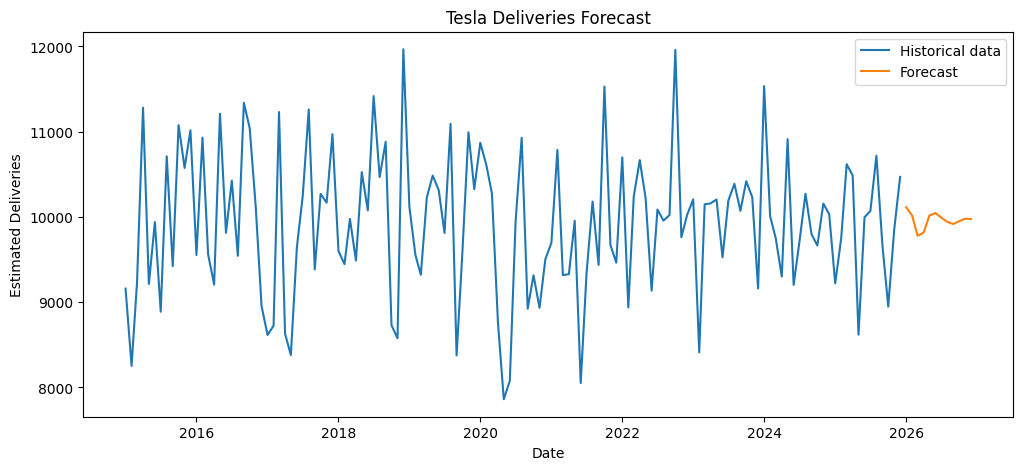

In [50]:
plt.figure(figsize=(12,5))

plt.plot(ts,label='Historical data')
plt.plot(forecast,label='Forecast')

plt.title('Tesla Deliveries Forecast')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')
plt.legend()
plt.show()

In [51]:
X_safe.columns

Index(['Year', 'Month', 'Region', 'Model', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type',
       'Charging_Stations', 'Price_Per_KM'],
      dtype='object')